# EEG Signal Classifier



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Data Loading And Transformation For Higher Feature Count

*Opening the Bonn EEG Dataset*

In [3]:
# NOTE: update this path to point at your local copy of the dataset.
DATA_PATH = "/Users/riyanshbalsekar/Desktop/EEG_Signal.csv"

data = pd.read_csv(DATA_PATH)

data.head()


,Signal,Labels,id person
0,40.0,A,Z092
1,48.0,A,Z092
2,35.0,A,Z092
3,5.0,A,Z092
4,-40.0,A,Z092


# Train Test Split

Split the dataset into aggregated data so the machine learning model can have data with more features

In [4]:
from sklearn.model_selection import train_test_split

train_ids, test_ids = train_test_split(data['id person'].unique(), test_size=0.2, random_state=42)

train_raw = data[data['id person'].isin(train_ids)]
test_raw = data[data['id person'].isin(test_ids)]

# Aggregate per-person signal statistics separately for train and test.
train_agg = train_raw.groupby('id person', as_index=False)['Signal'].agg(['mean', 'min', 'max', 'median', 'std'])
test_agg = test_raw.groupby('id person', as_index=False)['Signal'].agg(['mean', 'min', 'max', 'median', 'std'])

# Each person has a single label, so take the first value per group.
train_labels_raw = train_raw.groupby('id person', as_index=False)['Labels'].first()
test_labels_raw = test_raw.groupby('id person', as_index=False)['Labels'].first()

# Merge on 'id person' explicitly (rather than concatenating by position) so rows can never
# get misaligned even if a group is missing or the two aggregations return different ordering.
train_set = train_agg.merge(train_labels_raw, on='id person').drop(columns=['id person'])
test_set = test_agg.merge(test_labels_raw, on='id person').drop(columns=['id person'])

train_set, test_set


(          mean    min    max  median         std Labels
 0    28.570417  -64.0  123.0    29.0   28.628565      D
 1    31.778374 -269.0  893.0    26.0  133.492014      D
 2   -25.015865 -253.0  181.0   -27.0   71.966874      D
 3   -35.252136 -177.0   76.0   -35.0   37.806187      D
 4   -15.550647 -401.0  295.0   -25.0   84.295564      D
 ..         ...    ...    ...     ...         ...    ...
 395 -51.354162 -288.0  147.0   -51.0   43.810146      A
 396  -3.159873 -161.0  138.0    -2.0   41.225556      A
 397 -18.552355 -196.0  113.0   -18.0   42.272383      A
 398 -14.893581 -183.0  142.0   -15.0   45.039456      A
 399 -28.355626 -164.0  138.0   -30.0   42.072595      A
 
 [400 rows x 6 columns],
          mean    min    max  median         std Labels
 0  -33.691237 -114.0   45.0   -34.0   22.870402      D
 1  -16.213083 -115.0   84.0   -16.0   29.299433      D
 2   -3.758848 -124.0  105.0    -1.0   37.303789      D
 3    1.491579 -262.0  228.0     3.0   63.700180      D
 4  -21.4

# Exploring Data for Insights

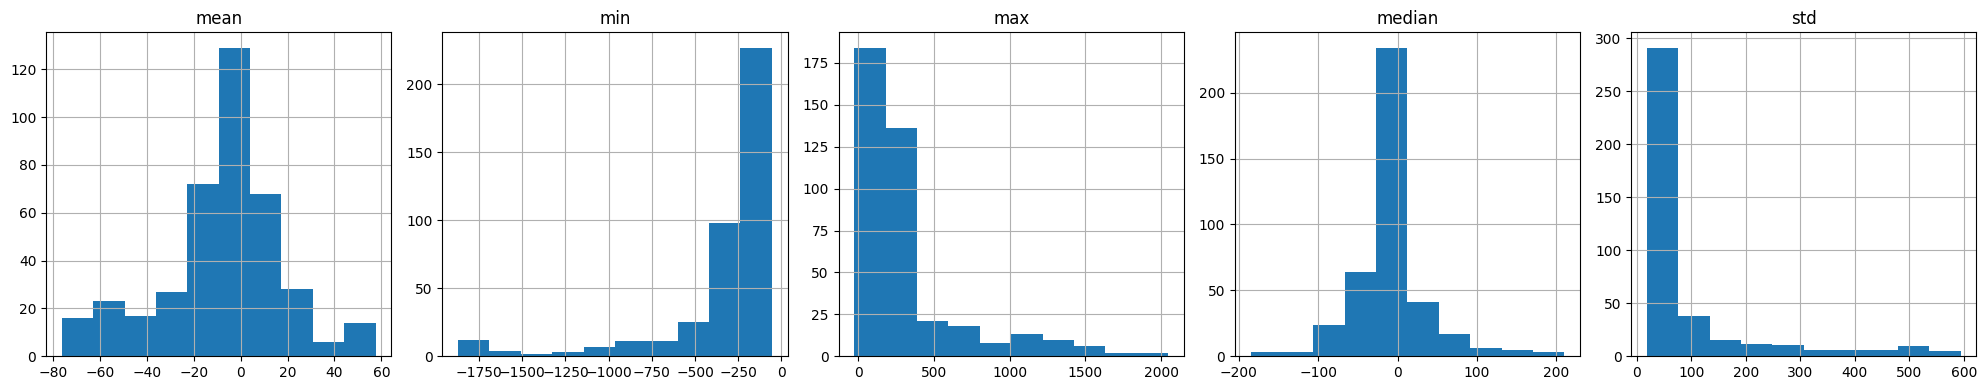

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, ['mean', 'min', 'max', 'median', 'std']):
    train_set[col].hist(ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


# Data Preprocessing

In [6]:
train_set


,mean,min,max,median,std,Labels
0,28.570417,-64.0,123.0,29.0,28.628565,D
1,31.778374,-269.0,893.0,26.0,133.492014,D
2,-25.015865,-253.0,181.0,-27.0,71.966874,D
3,-35.252136,-177.0,76.0,-35.0,37.806187,D
4,-15.550647,-401.0,295.0,-25.0,84.295564,D
...,...,...,...,...,...,...
395,-51.354162,-288.0,147.0,-51.0,43.810146,A
396,-3.159873,-161.0,138.0,-2.0,41.225556,A
397,-18.552355,-196.0,113.0,-18.0,42.272383,A
398,-14.893581,-183.0,142.0,-15.0,45.039456,A


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_labels = le.fit_transform(train_set['Labels'])
test_labels = le.transform(test_set['Labels'])

# Keep the feature frames separate from the encoded label arrays. These stay UNSCALED —
# scaling happens once, inside the `preprocessing` ColumnTransformer below, as part of
# each model's pipeline. (Previously the notebook scaled train_set/test_set here AND
# fed them into pipelines that scaled again — double-transforming the features.)
train_X = train_set.drop(columns=['Labels'])
test_X = test_set.drop(columns=['Labels'])


In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer

def signed_log(X):
    return np.sign(X) * np.log1p(np.abs(X))

log_pipeline = make_pipeline(FunctionTransformer(signed_log), StandardScaler())  # for std, max, min
num_pipeline = make_pipeline(StandardScaler())  # for mean, median

num_att = ['mean', 'median']
log_att = ['std', 'max', 'min']

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_att),
    ("log", log_pipeline, log_att),
])

# `preprocessing` is intentionally left UNFIT here — every downstream model wraps it in its
# own make_pipeline(preprocessing, Model), so each pipeline fits its own copy of the scaler
# on the training fold only. Fitting it here too, on top of that, was the double-scaling bug.


# Linear Regression

In [9]:
from sklearn.linear_model import LinearRegression

lin_model = make_pipeline(preprocessing, LinearRegression())

lin_model.fit(train_X, train_labels)

pred = lin_model.predict(test_X).round(0)
pred[:10]


array([1., 1., 1., 2., 3., 2., 1., 1., 1., 2.])

In [10]:
test_labels[:10]


array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [11]:
from sklearn.metrics import root_mean_squared_error, accuracy_score, mean_absolute_error

lin_rmse = root_mean_squared_error(test_labels, pred)
acc = accuracy_score(test_labels, pred)

acc
# values close to 1 point of error indicate the (rounded) regression output misses the class by about that much


0.24

# Decision Tree Classifier

In [12]:
from sklearn.tree import DecisionTreeClassifier

tree_model = make_pipeline(preprocessing, DecisionTreeClassifier(random_state=42))
tree_model.fit(train_X, train_labels)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('log', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [13]:
tree_pred = tree_model.predict(test_X)
tree_acc = accuracy_score(test_labels, tree_pred)
tree_acc


0.6

In [14]:
from sklearn.model_selection import cross_val_score

tree_cv_scores = cross_val_score(tree_model, train_X, train_labels, scoring="accuracy", cv=10)

pd.Series(tree_cv_scores).describe()


count    10.000000
mean      0.532500
std       0.067752
min       0.425000
25%       0.475000
50%       0.550000
75%       0.568750
max       0.625000
dtype: float64

 # Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

log_model = make_pipeline(preprocessing, LogisticRegression(random_state=0))
log_model.fit(train_X, train_labels)

log_pred = log_model.predict(test_X)
log_acc = accuracy_score(test_labels, log_pred)
log_acc


0.44

# Support Vector Machine

In [16]:
from sklearn.svm import SVC

svc_model = make_pipeline(preprocessing, SVC(kernel='rbf', C=1, gamma='scale'))
svc_model.fit(train_X, train_labels)

svc_pred = svc_model.predict(test_X)
svc_acc = accuracy_score(test_labels, svc_pred)
svc_acc


0.52

# Random Forest Classifier

In [17]:
from sklearn.ensemble import RandomForestClassifier

rfr_model = make_pipeline(preprocessing, RandomForestClassifier(random_state=42))
rfr_model.fit(train_X, train_labels)

rfr_pred = rfr_model.predict(test_X)
rfr_acc = accuracy_score(test_labels, rfr_pred)
rfr_acc


0.65

# KNN Classifier

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = make_pipeline(preprocessing, KNeighborsClassifier(n_neighbors=1, metric='minkowski', p=2))
knn_model.fit(train_X, train_labels)

knn_pred = knn_model.predict(test_X)
knn_acc = accuracy_score(test_labels, knn_pred)
knn_acc
# n_neighbors=1 memorizes the training data, so watch for a big gap between this test score
# and the training-set score below -- that gap is what "overfit" means here.


0.61

In [19]:
knn_train_acc = accuracy_score(train_labels, knn_model.predict(train_X))
knn_train_acc, knn_acc


(1.0, 0.61)

# Testing Models with Cross Validation

In [20]:
tree_rmse = cross_val_score(tree_model, train_X, train_labels, scoring="accuracy", cv=10)
pd.Series(tree_rmse).describe()


count    10.000000
mean      0.532500
std       0.067752
min       0.425000
25%       0.475000
50%       0.550000
75%       0.568750
max       0.625000
dtype: float64

In [21]:
log_rmse = cross_val_score(log_model, train_X, train_labels, scoring="accuracy", cv=10)
pd.Series(log_rmse).describe()


count    10.000000
mean      0.450000
std       0.086603
min       0.300000
25%       0.412500
50%       0.450000
75%       0.468750
max       0.625000
dtype: float64

In [22]:
svc_rmse = cross_val_score(svc_model, train_X, train_labels, scoring="accuracy", cv=10)
pd.Series(svc_rmse).describe()


count    10.000000
mean      0.492500
std       0.066719
min       0.350000
25%       0.475000
50%       0.487500
75%       0.525000
max       0.600000
dtype: float64

In [23]:
lin_cv_mae = -cross_val_score(lin_model, train_X, train_labels, scoring="neg_mean_absolute_error", cv=10)
pd.Series(lin_cv_mae).describe()


count    10.000000
mean      1.013441
std       0.427231
min       0.505484
25%       0.712512
50%       0.829714
75%       1.381981
max       1.646027
dtype: float64

# Grid Search with Random Forest Classifier

In [24]:
train_X


,mean,min,max,median,std
0,28.570417,-64.0,123.0,29.0,28.628565
1,31.778374,-269.0,893.0,26.0,133.492014
2,-25.015865,-253.0,181.0,-27.0,71.966874
3,-35.252136,-177.0,76.0,-35.0,37.806187
4,-15.550647,-401.0,295.0,-25.0,84.295564
...,...,...,...,...,...
395,-51.354162,-288.0,147.0,-51.0,43.810146
396,-3.159873,-161.0,138.0,-2.0,41.225556
397,-18.552355,-196.0,113.0,-18.0,42.272383
398,-14.893581,-183.0,142.0,-15.0,45.039456


In [25]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

model = make_pipeline(preprocessing, RandomForestClassifier(random_state=42))

param_grid = {
    'randomforestclassifier__max_depth': [5, 10, 15, 20, None],
    'randomforestclassifier__n_estimators': randint(100, 400),
    'randomforestclassifier__min_samples_leaf': randint(1, 5),
    'randomforestclassifier__bootstrap': [True, False]
}

search = RandomizedSearchCV(
    model,
    param_grid,
    cv=5,
    n_iter=100,   # try more combinations
    scoring='accuracy',
    random_state=42
)
search.fit(train_X, train_labels)

search.best_params_


{'randomforestclassifier__bootstrap': True,
 'randomforestclassifier__max_depth': None,
 'randomforestclassifier__min_samples_leaf': 1,
 'randomforestclassifier__n_estimators': 260}

In [26]:
rand_df = pd.DataFrame(search.cv_results_)
rand_df.sort_values(by="mean_test_score", ascending=False)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__bootstrap,param_randomforestclassifier__max_depth,param_randomforestclassifier__min_samples_leaf,param_randomforestclassifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
91,0.383294,0.008932,0.026564,0.000906,True,None,1,260,"{'randomforestclassifier__bootstrap': True, 'r...",0.6000,0.6250,0.5250,0.6125,0.6625,0.6050,0.045139,1
88,0.219728,0.022563,0.016082,0.000580,True,20,1,136,"{'randomforestclassifier__bootstrap': True, 'r...",0.6000,0.6000,0.5375,0.6125,0.6750,0.6050,0.043732,2
46,0.368959,0.013675,0.027584,0.004679,True,15,1,264,"{'randomforestclassifier__bootstrap': True, 'r...",0.6000,0.6250,0.5375,0.6000,0.6500,0.6025,0.037417,3
24,0.201535,0.020469,0.016361,0.000959,True,None,1,108,"{'randomforestclassifier__bootstrap': True, 'r...",0.6000,0.5750,0.5375,0.6375,0.6625,0.6025,0.044300,4
66,0.361574,0.009817,0.025809,0.001610,True,20,1,250,"{'randomforestclassifier__bootstrap': True, 'r...",0.5875,0.6250,0.5250,0.6125,0.6625,0.6025,0.045689,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,0.552912,0.036936,0.041775,0.005499,False,None,2,346,"{'randomforestclassifier__bootstrap': False, '...",0.5875,0.5500,0.5000,0.6000,0.6000,0.5675,0.038406,96
53,0.294909,0.017785,0.022185,0.001203,True,5,2,229,"{'randomforestclassifier__bootstrap': True, 'r...",0.6375,0.4875,0.5250,0.5875,0.6000,0.5675,0.053968,97
16,0.188854,0.044298,0.021170,0.003173,False,10,4,101,"{'randomforestclassifier__bootstrap': False, '...",0.6125,0.5500,0.5125,0.5750,0.5875,0.5675,0.034095,97
80,0.179602,0.013838,0.015675,0.002118,True,5,4,132,"{'randomforestclassifier__bootstrap': True, 'r...",0.6125,0.5000,0.5250,0.5875,0.6000,0.5650,0.044300,99


In [27]:
final_model = search.best_estimator_

final_prediction = final_model.predict(test_X)

final_score = accuracy_score(test_labels, final_prediction)

print(final_score)


0.65
